# 😊 Emotion Detection with YOLOv8 on FER2013 Dataset

This notebook demonstrates a full pipeline for training and testing a YOLOv8 model to recognize facial emotions using the FER2013 dataset.

### 🔧 Workflow Overview:

1. **Visualize Dataset**  
   Display one random image from each of the 7 emotion classes to explore the raw FER2013 data.

2. **Prepare Dataset for YOLO**  
   - Split the dataset into `train` (85%) and `val` (15%) sets.  
   - Create the folder structure required by YOLO.  
   - Generate YOLO-compatible labels assuming each image contains a single emotion.

3. **Configure YOLO Training**  
   - Write a `data.yaml` file that defines the dataset structure and emotion classes.  
   - Install the `ultralytics` library and load a YOLOv8-nano (`yolov8n.pt`) model.  
   - Train the model on the FER2013 dataset with augmentation and specified parameters.

This end-to-end workflow prepares, trains, and evaluates a YOLO model for facial emotion classification.


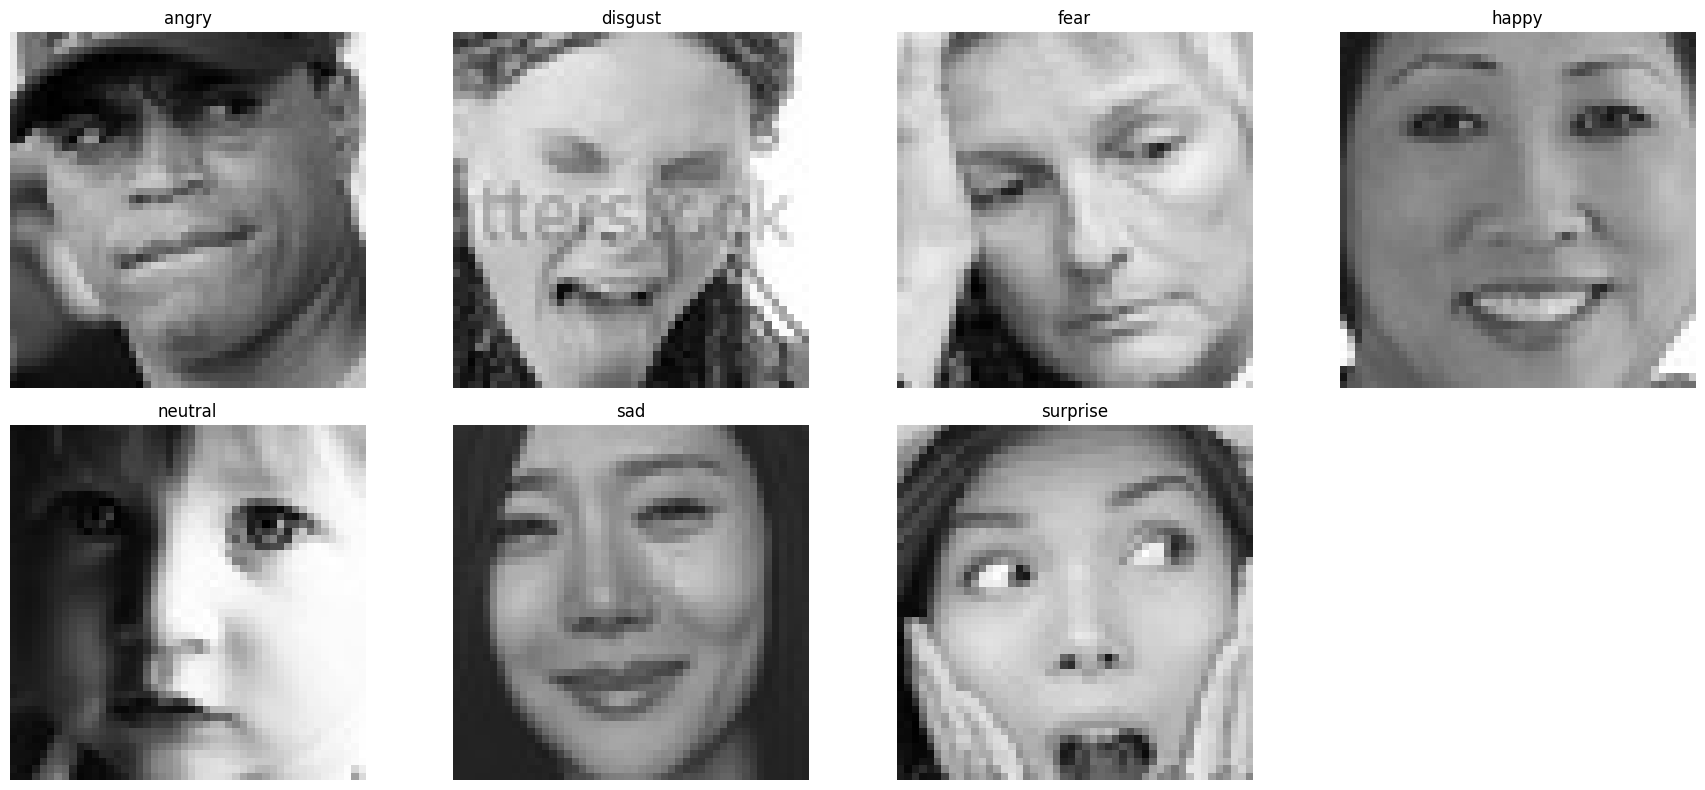

In [1]:
import matplotlib.pyplot as plt
import cv2
import os
import random

# FER2013 base path
fer_input_path = "/kaggle/input/fer2013/train"

# Emotion classes 
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Display 1 image per class
plt.figure(figsize=(18, 8))

for i, cls_name in enumerate(classes):
    class_dir = os.path.join(fer_input_path, cls_name)
    image_files = os.listdir(class_dir)
    img_file = random.choice(image_files)  # Random image from class

    img_path = os.path.join(class_dir, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(cls_name)
    plt.axis('off')

plt.tight_layout()
plt.show()


### 🖼️ Displaying One Image per Emotion Class from FER2013

This code visualizes a random image from each of the 7 emotion classes in the **FER2013 dataset** before any processing or YOLO formatting.

🔍 **What it does:**
- Iterates through the full list of emotion classes: `angry`, `disgust`, `fear`, `happy`, `neutral`, `sad`, `surprise`.
- For each class, it randomly selects one image from the corresponding directory.
- Displays all 7 images in a single figure using `matplotlib`.

✅ **Purpose:**
This helps verify the structure, variety, and quality of the raw dataset. It's a useful sanity check before proceeding to training or format conversion.


In [2]:
import os, shutil, glob, random

base_input = "/kaggle/input/fer2013"
base_output = "/kaggle/working/FER_YOLO"

classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Create folders
for split in ['train', 'val']:
    for sub in ['images', 'labels']:
        os.makedirs(os.path.join(base_output, split, sub), exist_ok=True)


### 📁 Organizing FER2013 Dataset for YOLO

This code sets up the folder structure needed to train a YOLO model using the FER2013 dataset. It does the following:

- Defines the input (`/kaggle/input/fer2013`) and output (`/kaggle/working/FER_YOLO`) paths.
- Lists the 7 emotion classes in the dataset.
- Creates subfolders under the output path for both training and validation sets:
  - `images/` to store the image files.
  - `labels/` to store the corresponding YOLO-format annotation files.

This is the standard directory format expected by YOLO for training.


In [3]:
for cls_id, cls_name in enumerate(classes):
    image_paths = glob.glob(f"{base_input}/train/{cls_name}/*.jpg")
    random.shuffle(image_paths)
    
    split_idx = int(0.85 * len(image_paths))
    splits = {
        'train': image_paths[:split_idx],
        'val': image_paths[split_idx:]
    }

    for split, paths in splits.items():
        for img_path in paths:
            fname = os.path.basename(img_path)
            out_img = os.path.join(base_output, split, 'images', f"{cls_name}_{fname}")
            out_lbl = os.path.join(base_output, split, 'labels', f"{cls_name}_{fname.replace('.jpg', '.txt')}")

            shutil.copy(img_path, out_img)

            # YOLO full image label: class_id x_center y_center width height (normalized)
            with open(out_lbl, 'w') as f:
                f.write(f"{cls_id} 0.01 0.01 0.01 .01\n")


### 🧪 Splitting and Labeling FER2013 Images for YOLO

This code processes the FER2013 dataset to prepare it for YOLO training. Here's what it does:

- Iterates through each emotion class using its index (`cls_id`) and name (`cls_name`).
- Gathers all image paths for the current class and shuffles them randomly.
- Splits the images into:
  - **85% for training**
  - **15% for validation**
- Copies each image to the appropriate folder (`train/images/` or `val/images/`) with a renamed filename that includes its class.
- Creates a corresponding YOLO label file in `labels/` where each image is labeled as:
  - The class ID.
  - A bounding box covering the **entire image** (`x_center=0.01, y_center=0.01, width=0.01, height=0.01`), assuming the emotion fills the whole image.

This step completes organizing the dataset into YOLO format with basic annotations, ready for training.


In [4]:
with open(f"{base_output}/data.yaml", "w") as f:
    f.write(
        f"path: {base_output}\n"
        f"train: train/images\n"
        f"val: val/images\n"
        f"names: {classes}\n"
    )


### 📝 Creating YOLO Configuration File (`data.yaml`)

This code generates a `data.yaml` file, which is required by YOLO for training. It includes the following information:

- `path`: The root directory containing the dataset (in YOLO format).
- `train`: The relative path to the training images folder.
- `val`: The relative path to the validation images folder.
- `names`: A list of all class names (emotion categories).

This configuration file helps YOLO locate the data and understand the class structure for training and evaluation.


In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existin

Installing needed Library to import YOLO

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  

results = model.train(
    data=f"{base_output}/data.yaml",
    epochs=50,
    workers=0,
    imgsz=640,
    batch=16,
    augment=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 125MB/s]


Ultralytics 8.3.160 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/FER_YOLO/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose

100%|██████████| 755k/755k [00:00<00:00, 29.8MB/s]


Overriding model.yaml nc=80 with nc=7

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

      48/50      2.95G     0.6581       1.87     0.7336          6        640: 100%|██████████| 1525/1525 [08:23<00:00,  3.03it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 135/135 [00:30<00:00,  4.40it/s]


                   all       4310       4310      0.213      0.856      0.121      0.119

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      49/50      2.96G      0.619      1.871     0.7338          8        640: 100%|██████████| 1525/1525 [08:22<00:00,  3.03it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 135/135 [00:30<00:00,  4.41it/s]


                   all       4310       4310      0.213      0.856       0.14      0.137

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      50/50      2.97G     0.5976      1.858     0.7326          9        640:  83%|████████▎ | 1267/1525 [06:59<01:22,  3.12it/s]

### 🚀 Training YOLOv8 on FER2013 Dataset

This code initializes and trains a **YOLOv8** model on the prepared FER2013 dataset:

- `YOLO("yolov8n.pt")`: Loads the **YOLOv8n** (nano) pre-trained model, which is lightweight and fast.
- `model.train(...)` starts the training process using the specified settings:
  - `data`: Path to the `data.yaml` configuration file.
  - `epochs`: Number of training epochs (50 in this case).
  - `workers`: Number of CPU workers (set to 0 for compatibility, e.g., in some Kaggle environments).
  - `imgsz`: Input image size (640x640).
  - `batch`: Batch size during training (16 images per batch).
  - `augment`: Enables data augmentation to improve generalization.

This step begins the actual training of the YOLO model to recognize emotions in facial images.
